# CSC5025 Intelligent Systems — Assignment 2

### Spatial Temporal Graph Neural Networks for vehicle traffic forecasting

---

In this notebook we use [**Torch Spatiotemporal (`tsl`)**](https://torch-spatiotemporal.readthedocs.io/)
to build, train and analyse **Spatiotemporal Graph Neural Networks (STGNNs)** for traffic
forecasting on the **full METR-LA** data set.

Three models are compared:

| Question | Model | Graph |
| :--- | :--- | :--- |
| **1** | `TimeThenSpaceModel` (TTS baseline) | predefined, distance-based |
| **2** | `GraphWaveNetModel` (GWN) | (i) predefined only, (ii) predefined + learned adaptive |
| **3** | `AGCRNModel` (AGCRN) | fully learned adaptive |

The workshop notebook *A Gentle Introduction to `tsl`* is used as the template: the data
pipeline, the Time-then-Space model and the training setup below are the workshop cells,
extended with the experiments, tables and plots required by the assignment brief.

**Experimental settings used for every experiment** (from the brief):

- holdout validation with a chronological `0.7 : 0.1 : 0.2` partition;
- `StandardScaler` fitted on the training split only;
- window size = 12 steps (60 minutes);
- prediction horizon = 12 steps (60 minutes);
- performance reported at horizons of 15, 30 and 60 minutes;
- the same split, metrics and hardware for every model.

## Quickstart

Google Colab already includes PyTorch. We will install the PyTorch Geometric extensions, Torch Spatiotemporal and TensorBoard required by this tutorial.

The compiled PyTorch Geometric extensions are selected to match the PyTorch and CUDA build available in the Colab runtime. Fixed package releases are used to reduce version-related differences during the practical session.

In [1]:
# Install the packages required by TSL and PyTorch Geometric.
# On Google Colab, uncomment the pip commands below. When running locally in the
# project environment (uv / venv) the dependencies are already installed.
import os
import torch

os.environ["TORCH"] = torch.__version__
print(f"PyTorch version: {torch.__version__}")

# !pip install -q torch-scatter \
#     -f https://data.pyg.org/whl/torch-${TORCH}.html

# !pip install -q torch-sparse \
#     -f https://data.pyg.org/whl/torch-${TORCH}.html

# !pip install -q torch-geometric==2.8.0.post1
# !pip install -q torch-spatiotemporal==0.9.5

PyTorch version: 2.4.1


For installation outside Google Colab, refer to the official
[TSL installation guide](https://torch-spatiotemporal.readthedocs.io/en/latest/usage/quickstart.html)
and
[PyTorch Geometric installation guide](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html).

Next, we will verify the installed versions and confirm that the libraries can be imported successfully.

In [2]:
import sys

import numpy as np
import pandas as pd
import torch
import torch_geometric
import tsl

print(f"Python version : {sys.version.split()[0]}")
print(f"tsl version    : {tsl.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version    : {torch_geometric.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

pd.options.display.float_format = "{:.2f}".format
np.set_printoptions(edgeitems=3, precision=3)
torch.set_printoptions(edgeitems=2, precision=3)

Python version : 3.12.9
tsl version    : 0.9.5
PyTorch version: 2.4.1
PyG version    : 2.8.0.post1
CUDA available : False


### Experiment configuration

One place for every knob that the assignment fixes, plus the training budget and the
mapping from a prediction horizon in minutes to a 0-based time-step index.

METR-LA is sampled every 5 minutes, so a forecast made for step `k` (0-based) is a
forecast `5 * (k + 1)` minutes ahead: 15 minutes is step `2`, 30 minutes is step `5`
and 60 minutes is step `11`. These are the same indices the workshop uses for
`MaskedMAE(at=...)`.

> **Runtime and memory note.** These runs use the *full* 207-sensor METR-LA data set
> (~24k training samples, ~375 optimiser steps per epoch), which is considerably
> heavier than the workshop's `limit_train_batches=50` demonstration budget.
>
> - Set `QUICK_RUN = True` to check that the whole notebook executes end to end
>   before committing to the real runs.
> - GraphWaveNet is the memory-hungry run: 8 blocks, each holding a
>   `[batch, 12, 207, 32]` activation plus a `[batch, 12, 207, 256]` skip connection.
>   If the machine runs out of memory, lower `batch_size` in the
>   `SpatioTemporalDataModule` cell below (32 or 16) rather than changing the model —
>   the brief fixes the model defaults, not the batch size.
> - Every run is checkpointed by fingerprint, so an interrupted session resumes from
>   the models it already finished instead of retraining them.

In [35]:
from pathlib import Path

# --- fixed by the assignment brief ----------------------------------------
WINDOW = 12            # 12 x 5 min = 60 minutes of history
HORIZON = 12           # 12 x 5 min = 60 minutes forecast
VAL_LEN = 0.1
TEST_LEN = 0.2         # -> 0.7 : 0.1 : 0.2 chronological holdout
BATCH_SIZE = 64

# Required reporting horizons -> 0-based index into the 12-step forecast.
HORIZON_STEPS = {15: 2, 30: 5, 60: 11}

# --- training budget -------------------------------------------------------
QUICK_RUN = False      # True -> tiny run for checking the notebook executes

SEED = 42
MAX_EPOCHS = 5 if QUICK_RUN else 15
PATIENCE = 2 if QUICK_RUN else 4          # early stopping on val_mae
LIMIT_TRAIN_BATCHES = 25 if QUICK_RUN else None   # None -> full epochs
AGCRN_PROBE_EPOCHS = 5 if QUICK_RUN else 30       # epoch-selection run (Q3)

ACCELERATOR = "cpu"   # "cpu" / "mps" / "gpu" / "auto"
DEVICES = 1

CKPT_DIR = Path("checkpoints_assignment2")
LOG_DIR = "logs_assignment2"

print(f"Training budget: max_epochs={MAX_EPOCHS}, patience={PATIENCE}, "
      f"limit_train_batches={LIMIT_TRAIN_BATCHES}")

Training budget: max_epochs=15, patience=4, limit_train_batches=None


## Loading and Preprocessing Data

### Loading a tabular dataset

`tsl` includes several datasets commonly used in spatiotemporal forecasting research. They are available through the [`tsl.datasets`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/datasets.html) module.

In this tutorial, we will use **METR-LA**, a widely used traffic forecasting benchmark. It contains traffic-speed measurements collected from **207 loop detectors** on highways in Los Angeles County.

The measurements were recorded every **5 minutes** over approximately four months, from March through June 2012.

We can download and load the dataset using the `MetrLA` class.

In [4]:
from tsl.datasets import MetrLA

# Download the dataset on the first run and cache it locally.
dataset = MetrLA(root="./data")

print(dataset)

/Users/tarique/School/UCT/Honours/Intelligent Systems/Assignments/Assignment2/.venv/lib/python3.12/site-packages/lightning_fabric/__init__.py:40: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


MetrLA(length=34272, n_nodes=207, n_channels=1)


/Users/tarique/School/UCT/Honours/Intelligent Systems/Assignments/Assignment2/.venv/lib/python3.12/site-packages/tsl/datasets/metr_la.py:109: FutureWarning: The 'method' keyword in DataFrame.replace is deprecated and will be removed in a future version.
  df = df.replace(to_replace=0., method='ffill')


All datasets in `tsl` inherit from the base
[`tsl.datasets.Dataset`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/datasets_prototypes.html#tsl.datasets.prototypes.Dataset)
class, which provides a common interface for spatiotemporal data.

The METR-LA observations have shape:

```text
(time, nodes, features)
```

For this dataset:

- **34,272 time steps** — one observation every 5 minutes;
- **207 nodes** — traffic loop detectors;
- **1 feature** — traffic speed at each detector.

Therefore:

```text
(34,272, 207, 1)
```

The dataset object also provides metadata and graph-related information used during preprocessing.

In [5]:
missing_percentage = (1 - dataset.mask.mean()) * 100

print(f"Sampling period: {dataset.freq}")
print(f"Has missing values: {dataset.has_mask}")
print(f"Percentage of missing values: {missing_percentage:.2f}%")
print(f"Mask shape: {dataset.mask.shape}")
print(f"Has covariates: {dataset.has_covariates}")
print(f"Covariates: {', '.join(dataset.covariates.keys())}")

Sampling period: <5 * Minutes>
Has missing values: True
Percentage of missing values: 8.11%
Mask shape: (34272, 207, 1)
Has covariates: True
Covariates: dist


The dataset contains missing observations. The binary `dataset.mask` has the same
time, node and feature dimensions as the observations:

- `1` indicates a valid observation;
- `0` indicates a missing observation.

METR-LA also provides `dist`, a static matrix containing pairwise distances
between sensor nodes. TSL exposes this information as a dataset covariate:

```python
dataset.dist
```

The distance matrix is graph-related information, but it is not yet the graph connectivity used by the model.


In [6]:
print(f"Distance matrix shape: {dataset.dist.shape}")

pd.DataFrame(dataset.dist).iloc[:8, :8]

Distance matrix shape: (207, 207)


,0,1,2,3,4,5,6,7
0,0.00,inf,inf,inf,inf,inf,inf,inf
1,inf,0.00,2504.60,8563.80,8572.50,9561.00,9590.00,2506.30
2,inf,1489.30,0.00,6971.30,6978.30,9148.20,9177.10,3995.70
3,inf,6805.90,9293.60,0.00,1745.50,6068.80,5401.50,9312.30
4,inf,6606.70,9111.30,1767.40,0.00,4464.00,3655.90,9113.10
5,inf,6596.00,9100.70,861.60,2607.20,0.00,4654.80,9102.40
6,inf,9452.80,inf,5264.40,6985.00,4402.80,0.00,inf
7,inf,5926.30,4436.70,inf,inf,inf,inf,0.00


The distance matrix has one row and one column for each sensor. Each finite
entry represents the available distance from one sensor to another, while
`inf` denotes sensor pairs for which no finite connection distance is provided.

This matrix is graph-related information, but it is not yet the adjacency
matrix used by the model. Later, we will transform these distances into sensor
similarities and graph connections.

Next, let us inspect the traffic-speed observations in tabular form.

In [7]:
speed_df = dataset.dataframe()

print(f"DataFrame shape: {speed_df.shape}")
speed_df.head()

DataFrame shape: (34272, 207)


nodes,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
channels,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2012-03-01 00:00:00,64.38,67.62,67.12,61.50,66.88,68.75,65.12,67.12,59.62,62.75,...,45.62,65.50,64.50,66.43,66.88,59.38,69.00,59.25,69.00,61.88
2012-03-01 00:05:00,62.67,68.56,65.44,62.44,64.44,68.11,65.00,65.00,57.44,63.33,...,50.67,69.88,66.67,58.56,62.00,61.11,64.44,55.89,68.44,62.88
2012-03-01 00:10:00,64.00,63.75,60.00,59.00,66.50,66.25,64.50,64.25,63.88,65.38,...,44.12,69.00,56.50,59.25,68.12,62.50,65.62,61.38,69.86,62.00
2012-03-01 00:15:00,64.00,63.75,60.00,59.00,66.50,66.25,64.50,64.25,63.88,65.38,...,44.12,69.00,56.50,59.25,68.12,62.50,65.62,61.38,69.86,62.00
2012-03-01 00:20:00,64.00,63.75,60.00,59.00,66.50,66.25,64.50,64.25,63.88,65.38,...,44.12,69.00,56.50,59.25,68.12,62.50,65.62,61.38,69.86,62.00


#### Inspecting one sensor time series

Before constructing the graph, we inspect three days of traffic speed at the first sensor. This shows the temporal variation that the forecasting model must represent.


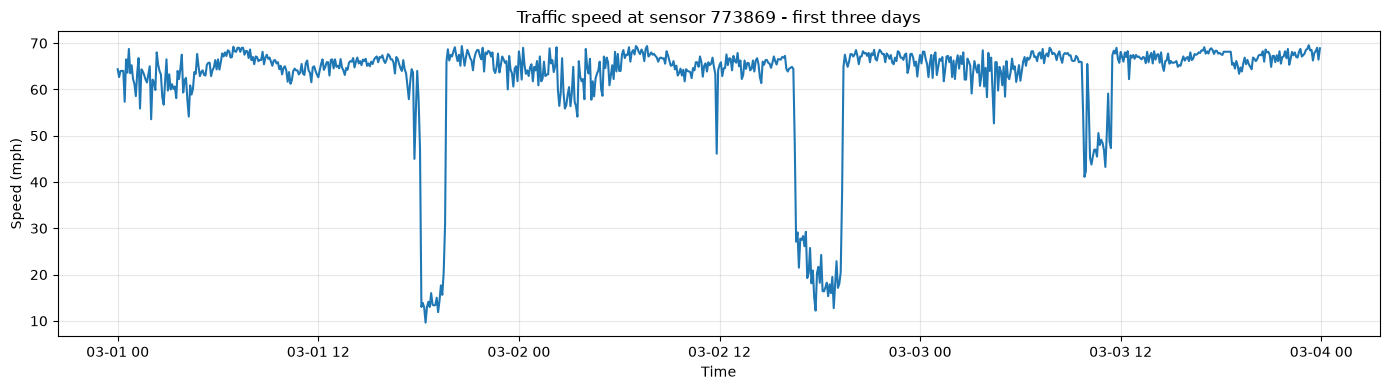

In [8]:
import matplotlib.pyplot as plt

# First three days: 3 × 24 × 12 five-minute observations.
sensor_idx = 0
sensor_series = speed_df.iloc[:864, sensor_idx]
sensor_column = speed_df.columns[sensor_idx]
sensor_id = sensor_column[0] if isinstance(sensor_column, tuple) else sensor_column

plt.figure(figsize=(14, 4))
plt.plot(sensor_series.index, sensor_series.values)
plt.title(f"Traffic speed at sensor {sensor_id} - first three days")
plt.xlabel("Time")
plt.ylabel("Speed (mph)")
plt.grid(alpha=0.3)
plt.tight_layout()

#### Connecting sensors

The traffic observations tell us what was measured at each sensor over time, but
they do not specify how the sensors are related.

To use a graph-based model, we must define connections between the sensor nodes.

`dataset.get_similarity()` computes pairwise node similarities using information
provided with the dataset. The available methods are stored in
`dataset.similarity_options`, and the default method is given by
`dataset.similarity_score`.

In [9]:
print(f"Default similarity: {dataset.similarity_score}")
print(f"Available similarity options: {dataset.similarity_options}")

sim = dataset.get_similarity("distance")

print(f"\nSimilarity matrix shape: {sim.shape}")
pd.DataFrame(sim).iloc[:8, :8]

Default similarity: distance
Available similarity options: {'distance'}

Similarity matrix shape: (207, 207)


,0,1,2,3,4,5,6,7
0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,1.00,0.39,0.00,0.00,0.00,0.00,0.39
2,0.00,0.72,1.00,0.00,0.00,0.00,0.00,0.09
3,0.00,0.00,0.00,1.00,0.63,0.00,0.01,0.00
4,0.00,0.00,0.00,0.63,1.00,0.05,0.14,0.00
5,0.00,0.00,0.00,0.89,0.36,1.00,0.04,0.00
6,0.00,0.00,0.00,0.02,0.00,0.05,1.00,0.00
7,0.00,0.01,0.05,0.00,0.00,0.00,0.00,1.00


The distance based similarity between sensors \(i\) and \(j\) is computed as

$$
w^{i,j} =
\begin{cases}
\exp\left(-\dfrac{\operatorname{dist}(i,j)^2}{\gamma}\right),
& \operatorname{dist}(i,j) \leq \delta, \\[6pt]
0, & \text{otherwise},
\end{cases}
$$

where:

- $\operatorname{dist}(i,j)$ is the distance from sensor $i$ to sensor $j$;
- $\gamma$ controls how quickly similarity decreases with distance;
- $\delta$ is a distance cut-off.

Nearby sensors receive larger similarity values, while sufficiently distant or
unconnected sensor pairs receive zero similarity.

The similarity matrix is not necessarily symmetric because the preprocessed
distance matrix is not symmetric.

We will now use `dataset.get_connectivity()` to:

1. obtain the default distance-based similarities;
2. remove similarity values below `0.1`;
3. remove self-connections;
4. normalise the edge weights;
5. return the graph in PyTorch Geometric's sparse `edge_index` layout.

> <font color="#1a73e8" size="4">**💡 Question:**</font>
>
> <font size="3">What is the difference between the distance matrix, similarity matrix and graph connectivity?</font>

In [10]:
connectivity = dataset.get_connectivity(
    threshold=0.1,
    include_self=False,
    normalize_axis=1,
    layout="edge_index",
)

The graph construction performs the following operations:

- compute the distance-based similarity matrix;
- set similarities below `0.1` to zero (`threshold=0.1`);
- remove self-loops (`include_self=False`);
- normalise incoming edge weights (`normalize_axis=1`);
- return PyTorch Geometric's sparse COO representation (`layout="edge_index"`).

The returned connectivity is:

```python
(edge_index, edge_weight)
```

In [11]:
edge_index, edge_weight = connectivity

print(f"edge_index shape: {edge_index.shape}")
print(edge_index)

print(f"\nedge_weight shape: {edge_weight.shape}")
print(edge_weight)

edge_index shape: (2, 1515)
[[  0   0   0 ... 206 206 206]
 [ 13  36  58 ... 157 162 198]]

edge_weight shape: (1515,)
[0.08  0.163 0.031 ... 0.045 0.031 0.115]


In the sparse COO representation:

- `edge_index` has shape `[2, E]`, where \(E\) is the number of edges;
- its first row contains source-node indices;
- its second row contains target-node indices;
- `edge_weight` contains one weight for each edge.

This representation stores only the existing graph connections rather than all
\(N^2\) possible node pairs.

The same graph can also be represented as a dense weighted adjacency matrix

$$
A \in \mathbb{R}^{N \times N}.
$$

In [12]:
from tsl.ops.connectivity import edge_index_to_adj

adj = edge_index_to_adj(edge_index, edge_weight)

print(f"Adjacency matrix shape: {adj.shape}")
pd.DataFrame(adj).iloc[:8, :8]

Adjacency matrix shape: (207, 207)


,0,1,2,3,4,5,6,7
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.14,0.00,0.00,0.00,0.00,0.14
2,0.00,0.19,0.00,0.00,0.00,0.00,0.00,0.00
3,0.00,0.00,0.00,0.00,0.12,0.00,0.00,0.00
4,0.00,0.00,0.00,0.11,0.00,0.00,0.02,0.00
5,0.00,0.00,0.00,0.18,0.07,0.00,0.00,0.00
6,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


#### Visualising the graph connectivity

The sparse edge representation can also be visualised as a dense weighted
adjacency matrix.

Rows represent target nodes, columns represent source nodes, and the colour
intensity represents the normalised edge weight.

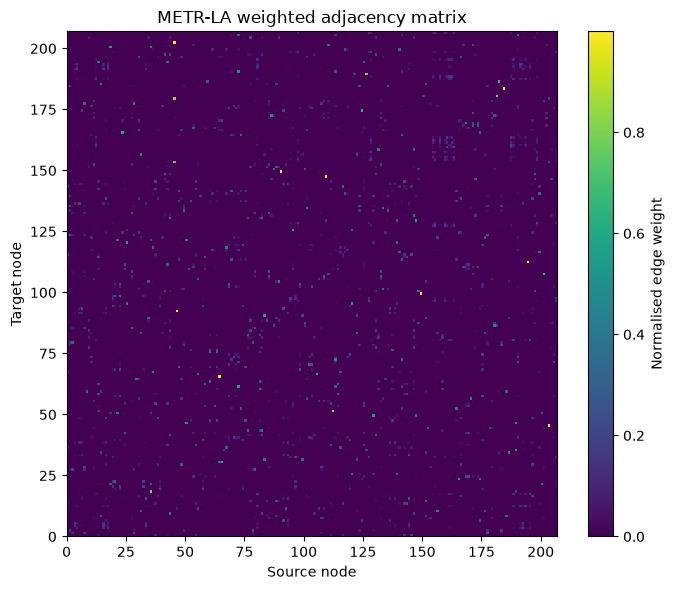

In [13]:
plt.figure(figsize=(7, 6))

image = plt.imshow(
    adj,
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    extent=[0, adj.shape[1], 0, adj.shape[0]],
)

plt.colorbar(image, label="Normalised edge weight")
plt.xlabel("Source node")
plt.ylabel("Target node")
plt.title("METR-LA weighted adjacency matrix")
plt.tight_layout()

The sparse edge weights can be retrieved from the dense adjacency matrix.

TSL follows the PyTorch Geometric convention in which an edge from source
\(i\) to target \(j\) is stored at adjacency entry \(A_{j,i}\). This explains
the reversed indexing order below.

In [14]:
source = edge_index[0]
target = edge_index[1]

print("Sparse edge weights:\n", adj[target, source])

Sparse edge weights:
 [0.08  0.163 0.031 ... 0.045 0.031 0.115]


### Building a PyTorch-ready dataset

[`SpatioTemporalDataset`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/data_pytorch_datasets.html#tsl.data.SpatioTemporalDataset)
converts the complete time series into PyTorch-ready forecasting samples.

It handles:

- sliding-window input–target pairs;
- graph connectivity and missing-value masks;
- conversion and organisation of data as model-ready tensors.

In [15]:
from tsl.data import SpatioTemporalDataset

torch_dataset = SpatioTemporalDataset(
    target=dataset.dataframe(),
    connectivity=connectivity,
    mask=dataset.mask,
    window=12,
    horizon=12,
    stride=1,
)

print(torch_dataset)

SpatioTemporalDataset(n_samples=34249, n_nodes=207, n_channels=1)


The original time series is divided into overlapping forecasting samples:

- `window=12`: use the previous 12 time steps as input;
- `horizon=12`: predict the following 12 time steps;
- `stride=1`: move forward by one time step to create the next sample.

Because METR-LA is sampled every 5 minutes, each sample uses one hour of past
traffic data to forecast the next hour. The complete input–target sample spans
24 time steps.

<p align="center">
  <img src="https://torch-spatiotemporal.readthedocs.io/en/latest/_images/sliding_window.svg" width="500em">
</p>

> <font color="#1a73e8" size="4">**💡 Question:**</font>
>
> <font size="3">What real-world periods do `window=12`, `horizon=12`, and `stride=1`
> represent for this dataset?</font>

### Spatiotemporal graph signals in TSL

Each item in `torch_dataset` is a spatiotemporal forecasting sample containing:

- a past input window;
- a future forecasting target;
- the sensor graph;
- a validity mask for the target values.

Samples can be accessed using ordinary Python indexing.

In [16]:
sample = torch_dataset[0]

print(sample)

Data(
  input=(x=[t=12, n=207, f=1], edge_index=[2, e=1515], edge_weight=[e=1515]),
  target=(y=[t=12, n=207, f=1]),
  has_mask=True
)


A sample is represented by [`tsl.data.Data`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/data_objects.html#tsl.data.Data),
which extends the PyTorch Geometric `Data` object for spatiotemporal signals.

The main attributes used in this tutorial are:

- `sample.input.x`: the past input window;
- `sample.target.y`: the future forecasting target;
- `sample.edge_index`: graph connections in sparse COO format;
- `sample.edge_weight`: the corresponding graph weights;
- `sample.mask`: valid values in the forecasting target;
- `sample.pattern`: labels describing tensor dimensions such as time, nodes,
  features and edges.

We will inspect these tensors and their shapes next.

#### Input and target views

`Data.input` and `Data.target` provide views of the tensors stored in the same `Data` object. In this tutorial, `sample.input` contains the historical window and graph inputs, while `sample.target` contains the future traffic-speed target.

In [17]:
sample.input.to_dict()

{'x': tensor([[[64.375],
          [67.625],
          ...,
          [69.000],
          [61.875]],
 
         [[62.667],
          [68.556],
          ...,
          [68.444],
          [62.875]],
 
         ...,
 
         [[65.222],
          [63.667],
          ...,
          [67.222],
          [60.000]],
 
         [[62.250],
          [67.750],
          ...,
          [66.500],
          [59.429]]]),
 'edge_index': tensor([[  0,   0,  ..., 206, 206],
         [ 13,  36,  ..., 162, 198]]),
 'edge_weight': tensor([0.080, 0.163,  ..., 0.031, 0.115])}

In [18]:
sample.target.to_dict()

{'y': tensor([[[61.125],
          [67.000],
          ...,
          [70.000],
          [63.500]],
 
         [[58.556],
          [62.667],
          ...,
          [66.222],
          [62.333]],
 
         ...,
 
         [[63.222],
          [64.111],
          ...,
          [67.333],
          [63.000]],
 
         [[65.000],
          [63.000],
          ...,
          [64.125],
          [60.750]]])}

#### Mask and transformations

`sample.mask` identifies valid forecasting targets.

`sample.transform` stores any preprocessing transformations associated with the
sample. No transformation has been added yet.


In [19]:
if sample.has_mask:
    print(sample.mask)
else:
    print("Sample has no mask.")

tensor([[[True],
         [True],
         ...,
         [True],
         [True]],

        [[True],
         [True],
         ...,
         [True],
         [True]],

        ...,

        [[True],
         [True],
         ...,
         [True],
         [True]],

        [[True],
         [True],
         ...,
         [True],
         [True]]])


In [20]:
if sample.has_transform:
    print(sample.transform)
else:
    print("Sample has no transformations.")

Sample has no transformations.


#### Tensor patterns

The `pattern` mapping describes the meaning of each tensor dimension:

- `t`: time steps;
- `n`: nodes;
- `e`: edges;
- `f`: features;
- `b`: batch.

In [21]:
print("Tensor patterns:")
print(sample.pattern)

print("\nSample shapes:")
print(sample)

Tensor patterns:
{'x': 't n f', 'mask': 't n f', 'edge_index': '2 e', 'edge_weight': 'e', 'y': 't n f'}

Sample shapes:
Data(
  input=(x=[t=12, n=207, f=1], edge_index=[2, e=1515], edge_weight=[e=1515]),
  target=(y=[t=12, n=207, f=1]),
  has_mask=True
)


### Batching spatiotemporal graph signals

Multiple forecasting samples can be stacked into a batch while sharing the same
sensor graph.


In [22]:
batch = torch_dataset[:5]

print(batch)

StaticBatch(
  input=(x=[b=5, t=12, n=207, f=1], edge_index=[2, e=1515], edge_weight=[e=1515]),
  target=(y=[b=5, t=12, n=207, f=1]),
  has_mask=True
)


The batch dimension `b` is added to the time-varying tensors:

- `x`: historical input windows;
- `y`: future targets;
- `mask`: valid target values.

For five samples:

```text
[batch, time, nodes, features]
[5, 12, 207, 1]
```

The graph does not receive an additional batch dimension because all samples share the same fixed sensor graph.

> **Interpret the output**
>
> What do the dimensions `[5, 12, 207, 1]` represent?

### Preparing the dataset for training

Before training, we need to:

1. split the forecasting samples chronologically into training, validation and
   test sets;
2. scale the data using statistics computed from the training set.

[`SpatioTemporalDataModule`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/data_datamodule.html#tsl.data.datamodule.SpatioTemporalDataModule)
coordinates the data splits, preprocessing and mini-batch creation used during
training.

In [23]:
from tsl.data.datamodule import SpatioTemporalDataModule, TemporalSplitter
from tsl.data.preprocessing import StandardScaler

# Standardise the traffic feature across training times and sensor nodes.
scalers = {
    "target": StandardScaler(axis=(0, 1))
}

# Split samples chronologically:
# |---------- complete dataset ----------|
# |------ train ------|-- val --|-- test --|
splitter = TemporalSplitter(
    val_len=0.1,
    test_len=0.2,
)

dm = SpatioTemporalDataModule(
    dataset=torch_dataset,
    scalers=scalers,
    splitter=splitter,
    batch_size=64,
)

print(dm.shape)

(34272, 207, 1)


The data module uses a **lazy setup**: creating `dm` stores the configuration,
but does not yet split or scale the data.

We perform these operations explicitly by calling `dm.setup()`.

In [24]:
dm.setup()

print(dm)

SpatioTemporalDataModule(train_len=24648, val_len=2728, test_len=6849, scalers=[target], batch_size=64)


During `setup()`, the data module:

1. divides the forecasting samples into chronological training, validation and
   test sets;
2. fits the scaler using only the training data;
3. applies the fitted transformation consistently to the three subsets.

> <font color="#1a73e8" size="4">**💡 Question:**</font>
>
> <font size="3">Why must the scaler be fitted only on the training data?</font>

#### Splitters

A splitter defines how samples are assigned to the training, validation and test
sets.

Here, `TemporalSplitter` preserves chronological order rather than randomly
dividing the time series.

[Read more about TSL splitters](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/data_datamodule.html#splitters).

#### Scalers

TSL scalers provide methods similar to those in scikit-learn:

- `fit`;
- `transform`;
- `fit_transform`;
- `inverse_transform`.

`StandardScaler` subtracts the training mean and divides by the training
standard deviation. Predictions can later be transformed back to the original
traffic-speed units.

[Read more about TSL scalers](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/data_preprocessing.html#scalers).

The split above is exactly the `0.7 : 0.1 : 0.2` holdout required by the brief:
`TemporalSplitter(val_len=0.1, test_len=0.2)` assigns the remaining 70% of the
chronologically-ordered samples to training, and `StandardScaler` is fitted on that
training portion only.

`batch_size=64` is the workshop's value and is the one knob to turn if GraphWaveNet
runs out of memory later — reduce it to 32 or 16 and re-run from this cell. The brief
fixes the split, the scaler, the window and the horizon, but not the batch size.

In [25]:
import pytorch_lightning as pl

pl.seed_everything(SEED, workers=True)

n_train = len(dm.trainset)
n_val = len(dm.valset)
n_test = len(dm.testset)
n_total = n_train + n_val + n_test

print(f"train: {n_train:6d} samples ({n_train / n_total:.1%})")
print(f"val  : {n_val:6d} samples ({n_val / n_total:.1%})")
print(f"test : {n_test:6d} samples ({n_test / n_total:.1%})")

# Wall-clock timestamps of each forecasting target, used later for the
# per-station actual-versus-predicted plots.
time_index = dataset.dataframe().index
test_sample_starts = np.asarray(dm.testset.indices)


def target_times(step: int) -> pd.DatetimeIndex:
    """Timestamps of forecast step ``step`` (0-based) for every test sample."""
    return time_index[test_sample_starts + WINDOW + step]


print(f"\nTest period: {target_times(0)[0]} -> {target_times(HORIZON - 1)[-1]}")

Seed set to 42


train:  24648 samples (72.0%)
val  :   2728 samples (8.0%)
test :   6849 samples (20.0%)

Test period: 2012-06-04 04:20:00 -> 2012-06-27 23:55:00


---

## Experiment utilities

Three questions, four trained models and a per-station analysis need the same machinery
each time, so it is defined once here:

1. **`train_or_load`** — fits a model with PyTorch Lightning, times the run, records the
   epoch-wise metrics for the convergence plots, and caches the best checkpoint on disk.
   Re-running a cell that has already been fitted with an identical configuration reloads
   the weights instead of retraining. Changing any hyperparameter changes the fingerprint
   and forces a genuine retrain.
2. **`evaluate`** — streams the test set through a trained model and accumulates masked
   error sums per (forecast step, sensor). That gives the average MSE / MAPE / MAE across
   all 207 sensors *and* the per-sensor breakdown from a single pass, without ever holding
   all ~6.8k x 12 x 207 predictions in memory.
3. plotting and table helpers for the horizon, convergence and per-station figures.

All metrics are masked exactly as `tsl` masks them: entries where `dataset.mask` is zero
(missing observations, which METR-LA encodes as zero speed) are excluded from every
average, so MAPE never divides by a missing zero.

In [26]:
# --- training with a checkpoint cache --------------------------------------
import hashlib
import json
import shutil
import time

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint


class EpochHistory(pl.Callback):
    """Record the metrics Lightning logs at each epoch, for convergence plots."""

    def __init__(self):
        self.by_epoch = {}

    def _grab(self, trainer):
        if trainer.sanity_checking:
            return
        epoch = int(trainer.current_epoch)
        row = self.by_epoch.setdefault(epoch, {"epoch": epoch})
        row["step"] = int(trainer.global_step)
        for key, value in trainer.callback_metrics.items():
            try:
                row[key] = float(value)
            except (TypeError, ValueError):
                pass

    # Lightning fires these in a version-dependent order, so grab at both points
    # and merge into the same per-epoch row.
    def on_validation_epoch_end(self, trainer, pl_module):
        self._grab(trainer)

    def on_train_epoch_end(self, trainer, pl_module):
        self._grab(trainer)

    def rows(self):
        return [self.by_epoch[e] for e in sorted(self.by_epoch)]


def run_fingerprint(predictor, train_cfg: dict) -> str:
    """Short hash identifying this architecture *and* training configuration.

    Everything that would change the resulting weights goes into the hash, so editing
    a hyperparameter yields a new filename and forces a genuine retrain rather than
    silently reusing weights that no longer correspond to the code.
    """
    model = predictor.model
    spec = {
        "model_class": type(model).__name__,
        "architecture": str(model),   # spells out every submodule and its dimensions
        "n_params": sum(p.numel() for p in model.parameters()),
        "optimizer": getattr(predictor.optim_class, "__name__", None),
        "optim_kwargs": predictor.optim_kwargs,
        "train_cfg": train_cfg,
    }
    blob = json.dumps(spec, sort_keys=True, default=str).encode()
    return hashlib.sha256(blob).hexdigest()[:12]


RUNS = {}   # name -> {"predictor", "trainer", "ckpt", "meta"}


def train_or_load(name, predictor, dm, *, max_epochs=None, patience=None,
                  limit_train_batches=None, accelerator=ACCELERATOR, devices=DEVICES,
                  logger=None, force_retrain=False):
    """Fit ``predictor``, or reuse a cached checkpoint from an identical run.

    Returns the run record, which is also stored in ``RUNS[name]``. Each model gets its
    own directory, so models never overwrite each other's checkpoints.
    """
    max_epochs = MAX_EPOCHS if max_epochs is None else max_epochs
    patience = PATIENCE if patience is None else patience
    if limit_train_batches is None:
        limit_train_batches = LIMIT_TRAIN_BATCHES

    train_cfg = {
        "max_epochs": max_epochs,
        "patience": patience,
        "limit_train_batches": limit_train_batches,
        "batch_size": dm.batch_size,
        "window": WINDOW,
        "horizon": HORIZON,
        "val_len": VAL_LEN,
        "test_len": TEST_LEN,
        "seed": SEED,
    }
    fingerprint = run_fingerprint(predictor, train_cfg)

    run_dir = CKPT_DIR / name
    run_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = run_dir / f"{fingerprint}.ckpt"
    meta_path = run_dir / f"{fingerprint}.json"

    # A trainer is built either way: the cached branch still needs one for .test().
    history = EpochHistory()
    checkpoint_callback = ModelCheckpoint(dirpath=run_dir / "raw",
                                          filename=f"{fingerprint}-{{epoch}}",
                                          save_top_k=1,
                                          monitor="val_mae",
                                          mode="min")
    callbacks = [checkpoint_callback, history]
    if patience:
        callbacks.append(EarlyStopping(monitor="val_mae", mode="min",
                                       patience=patience))

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        logger=logger,
        accelerator=accelerator,
        devices=devices,
        limit_train_batches=1.0 if limit_train_batches is None else limit_train_batches,
        callbacks=callbacks,
    )

    if ckpt_path.exists() and not force_retrain:
        predictor.load_model(str(ckpt_path))
        meta = json.loads(meta_path.read_text()) if meta_path.exists() else {}
        print(f"[cache hit ] {name}: loaded {ckpt_path}  (skipping training)")
        record = {"predictor": predictor, "trainer": trainer,
                  "ckpt": ckpt_path, "meta": meta}
        RUNS[name] = record
        return record

    reason = "force_retrain=True" if ckpt_path.exists() else "no cached checkpoint"
    print(f"[cache miss] {name}: {reason} -> training")

    start = time.perf_counter()
    trainer.fit(predictor, datamodule=dm)
    train_seconds = time.perf_counter() - start

    best = checkpoint_callback.best_model_path
    if not best:
        raise RuntimeError(
            f"{name}: no checkpoint was written -- is 'val_mae' being logged?")
    shutil.copyfile(best, ckpt_path)

    rows = history.rows()
    val_maes = [(r["epoch"], r["val_mae"]) for r in rows if "val_mae" in r]
    best_epoch = min(val_maes, key=lambda kv: kv[1])[0] if val_maes else None

    meta = {
        "name": name,
        "fingerprint": fingerprint,
        "model_class": type(predictor.model).__name__,
        "n_params": sum(p.numel() for p in predictor.model.parameters()),
        "train_cfg": train_cfg,
        "epochs_run": len(rows),
        "best_epoch": best_epoch,
        "best_val_mae": float(checkpoint_callback.best_model_score),
        "train_seconds": train_seconds,
        "seconds_per_epoch": train_seconds / max(len(rows), 1),
        "accelerator": str(trainer.strategy.root_device),
        "history": rows,
        "source_checkpoint": best,
    }
    meta_path.write_text(json.dumps(meta, indent=2))

    # Continue from the *best* epoch, not from the last one.
    predictor.load_model(str(ckpt_path))

    print(f"[saved     ] {name}: {ckpt_path} "
          f"(val_mae={meta['best_val_mae']:.4f}, best epoch={best_epoch}, "
          f"{train_seconds / 60:.1f} min)")

    record = {"predictor": predictor, "trainer": trainer,
              "ckpt": ckpt_path, "meta": meta}
    RUNS[name] = record
    return record


def list_cached():
    """Show what is currently cached on disk."""
    rows = sorted(CKPT_DIR.glob("*/*.json"))
    if not rows:
        print(f"No cached models under {CKPT_DIR}/")
        return
    for meta_file in rows:
        info = json.loads(meta_file.read_text())
        size = meta_file.with_suffix(".ckpt").stat().st_size / 1e6
        print(f"{info['name']:22s} {info['model_class']:20s} "
              f"val_mae={info['best_val_mae']:.4f}  "
              f"{info.get('train_seconds', float('nan')) / 60:6.1f} min  "
              f"{size:6.1f} MB  {info['fingerprint']}")

In [27]:
# --- evaluation: masked error sums per (forecast step, sensor) --------------
EPS = 1e-8


def pick_device(accelerator=ACCELERATOR):
    if accelerator == "cpu":
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@torch.no_grad()
def evaluate(name, predictor, dm, split="test", keep_nodes=3, device=None):
    """Run ``predictor`` over ``split`` and accumulate masked errors.

    Returns a dict with, for every forecast step and every sensor, the masked MAE,
    MSE and MAPE, plus the raw actual/predicted series for the first ``keep_nodes``
    sensors (needed for the per-station plots).
    """
    device = device or pick_device()
    predictor.eval().to(device)
    loader = getattr(dm, f"{split}_dataloader")()

    n_t, n_n = torch_dataset.horizon, torch_dataset.n_nodes
    shape = (n_t, n_n)
    abs_sum = torch.zeros(shape, dtype=torch.float64, device=device)
    sq_sum = torch.zeros(shape, dtype=torch.float64, device=device)
    ape_sum = torch.zeros(shape, dtype=torch.float64, device=device)
    count = torch.zeros(shape, dtype=torch.float64, device=device)

    kept_y, kept_hat, kept_mask = [], [], []

    for batch in loader:
        batch = batch.to(device)
        y, y_hat, mask = predictor.predict_batch(batch, postprocess=True,
                                                 return_target=True)
        # Drop the (single) feature axis: [b, t, n, 1] -> [b, t, n]
        y, y_hat = y[..., 0], y_hat[..., 0]
        m = (torch.ones_like(y) if mask is None else mask[..., 0].to(y.dtype))

        err = (y_hat - y) * m
        abs_sum += err.abs().sum(0).double()
        sq_sum += err.pow(2).sum(0).double()
        # clamp() keeps the division finite where a masked-out target is zero;
        # the * m then removes those entries from the sum entirely.
        ape_sum += ((y_hat - y).abs() / y.abs().clamp(min=EPS) * m).sum(0).double()
        count += m.sum(0).double()

        if keep_nodes:
            kept_y.append(y[:, :, :keep_nodes].cpu())
            kept_hat.append(y_hat[:, :, :keep_nodes].cpu())
            kept_mask.append(m[:, :, :keep_nodes].cpu())

    predictor.to("cpu")   # free the accelerator between models

    safe = count.clamp(min=1.0)
    per_node = {
        "MAE": (abs_sum / safe).cpu().numpy(),
        "MSE": (sq_sum / safe).cpu().numpy(),
        "MAPE": (100.0 * ape_sum / safe).cpu().numpy(),
    }
    per_step_total = count.sum(1).clamp(min=1.0)
    per_step = pd.DataFrame({
        "MSE": (sq_sum.sum(1) / per_step_total).cpu().numpy(),
        "MAPE": (100.0 * ape_sum.sum(1) / per_step_total).cpu().numpy(),
        "MAE": (abs_sum.sum(1) / per_step_total).cpu().numpy(),
    }, index=pd.Index(np.arange(1, n_t + 1) * 5, name="minutes ahead"))

    grand = count.sum().clamp(min=1.0)
    overall = {
        "MSE": float(sq_sum.sum() / grand),
        "MAPE": float(100.0 * ape_sum.sum() / grand),
        "MAE": float(abs_sum.sum() / grand),
    }

    result = {
        "name": name,
        "per_step": per_step,
        "per_node": per_node,
        "overall": overall,
        "n_obs": float(count.sum()),
    }
    if keep_nodes:
        result["y"] = torch.cat(kept_y).numpy()          # [samples, horizon, keep]
        result["y_hat"] = torch.cat(kept_hat).numpy()
        result["mask"] = torch.cat(kept_mask).numpy().astype(bool)
    return result


RESULTS = {}   # name -> evaluate(...) output

In [28]:
# --- tables and figures -----------------------------------------------------
METRICS = ["MSE", "MAPE", "MAE"]
METRIC_LABEL = {"MSE": "MSE (mph$^2$)", "MAPE": "MAPE (%)", "MAE": "MAE (mph)"}


def horizon_table(result, minutes=(15, 30, 60)):
    """Average MSE / MAPE / MAE across all 207 sensors at the required horizons."""
    rows = {f"{m} min": result["per_step"].loc[m] for m in minutes}
    table = pd.DataFrame(rows).T[METRICS]
    table.loc["all 12 steps"] = [result["overall"][k] for k in METRICS]
    table.index.name = "horizon"
    return table


def comparison_table(names, minutes=(15, 30, 60), metrics=METRICS):
    """One row per model, one column per (metric, horizon)."""
    frames = {}
    for name in names:
        table = horizon_table(RESULTS[name], minutes)
        flat = {}
        for metric in metrics:
            for row in table.index:
                flat[(metric, row)] = table.loc[row, metric]
        frames[name] = flat
    out = pd.DataFrame(frames).T
    out.columns = pd.MultiIndex.from_tuples(out.columns, names=["metric", "horizon"])
    out.index.name = "model"
    return out


def plot_horizon_metrics(results, minutes=(15, 30, 60), title=""):
    """MSE / MAPE / MAE against prediction horizon, one panel per metric."""
    if isinstance(results, dict) and "per_step" in results:
        results = [results]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, METRICS):
        for result in results:
            values = [result["per_step"].loc[m, metric] for m in minutes]
            ax.plot(minutes, values, marker="o", label=result["name"])
        ax.set_xlabel("Prediction horizon (minutes)")
        ax.set_ylabel(METRIC_LABEL[metric])
        ax.set_title(metric)
        ax.set_xticks(list(minutes))
        ax.grid(alpha=0.3)
    if len(results) > 1:
        axes[-1].legend(fontsize=8)
    fig.suptitle(title or "Average test performance across all 207 sensors")
    fig.tight_layout()
    plt.show()


def per_node_table(names, nodes=(0, 1, 2), minutes=(15, 30, 60)):
    """Per-sensor MSE / MAPE / MAE at each required horizon, for selected models."""
    rows = []
    for name in names:
        result = RESULTS[name]
        for node in nodes:
            for m in minutes:
                step = HORIZON_STEPS[m]
                rows.append({
                    "model": name,
                    "sensor": f"{node} ({sensor_ids[node]})",
                    "horizon": f"{m} min",
                    **{metric: result["per_node"][metric][step, node]
                       for metric in METRICS},
                })
    return (pd.DataFrame(rows)
            .set_index(["sensor", "horizon", "model"])
            .sort_index()[METRICS])


def plot_per_node_metrics(names, nodes=(0, 1, 2), minutes=(15, 30, 60)):
    """Grouped bars: one row per sensor, one panel per metric."""
    fig, axes = plt.subplots(len(nodes), 3, figsize=(15, 3.4 * len(nodes)),
                             squeeze=False)
    width = 0.8 / len(names)
    x = np.arange(len(minutes))
    for r, node in enumerate(nodes):
        for c, metric in enumerate(METRICS):
            ax = axes[r][c]
            for k, name in enumerate(names):
                values = [RESULTS[name]["per_node"][metric][HORIZON_STEPS[m], node]
                          for m in minutes]
                ax.bar(x + k * width, values, width, label=name)
            ax.set_xticks(x + width * (len(names) - 1) / 2)
            ax.set_xticklabels([f"{m} min" for m in minutes])
            ax.set_ylabel(METRIC_LABEL[metric])
            ax.grid(alpha=0.3, axis="y")
            if c == 0:
                ax.set_title(f"sensor {node} ({sensor_ids[node]}) — {metric}")
            else:
                ax.set_title(metric)
    axes[0][-1].legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_actual_vs_predicted(names, nodes=(0, 1, 2), minutes=15, n_samples=576,
                             offset=0):
    """Actual versus predicted traffic speed over a slice of the test set.

    ``n_samples=576`` is two days of 5-minute test samples at a fixed lead time.
    """
    step = HORIZON_STEPS[minutes]
    times = target_times(step)[offset:offset + n_samples]
    sl = slice(offset, offset + n_samples)

    fig, axes = plt.subplots(len(nodes), 1, figsize=(14, 3.2 * len(nodes)),
                             squeeze=False)
    for r, node in enumerate(nodes):
        ax = axes[r][0]
        first = RESULTS[names[0]]
        actual = first["y"][sl, step, node].astype(float)
        valid = first["mask"][sl, step, node]
        ax.plot(times, np.where(valid, actual, np.nan), color="black",
                linewidth=1.4, label="Actual")
        for name in names:
            ax.plot(times, RESULTS[name]["y_hat"][sl, step, node],
                    linewidth=1.1, alpha=0.85, label=f"Predicted — {name}")
        ax.set_title(f"Sensor {node} ({sensor_ids[node]}) — "
                     f"{minutes} minute ahead forecast on the test set")
        ax.set_ylabel("Speed (mph)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, ncol=len(names) + 1)
    axes[-1][0].set_xlabel("Time")
    fig.tight_layout()
    plt.show()


def plot_scatter(names, nodes=(0, 1, 2), minutes=15, max_points=4000):
    """Predicted against actual, to expose bias and variance per sensor."""
    step = HORIZON_STEPS[minutes]
    fig, axes = plt.subplots(len(names), len(nodes),
                             figsize=(4 * len(nodes), 3.8 * len(names)),
                             squeeze=False)
    for r, name in enumerate(names):
        result = RESULTS[name]
        for c, node in enumerate(nodes):
            ax = axes[r][c]
            valid = result["mask"][:, step, node]
            actual = result["y"][valid, step, node]
            predicted = result["y_hat"][valid, step, node]
            if len(actual) > max_points:
                idx = np.linspace(0, len(actual) - 1, max_points).astype(int)
                actual, predicted = actual[idx], predicted[idx]
            ax.scatter(actual, predicted, s=3, alpha=0.2)
            lim = [0, max(actual.max(), predicted.max()) * 1.05]
            ax.plot(lim, lim, color="red", linewidth=1, linestyle="--")
            ax.set_xlim(lim)
            ax.set_ylim(lim)
            ax.set_xlabel("Actual (mph)")
            ax.set_ylabel("Predicted (mph)")
            ax.set_title(f"{name} — sensor {node}", fontsize=9)
            ax.grid(alpha=0.3)
    fig.suptitle(f"Predicted versus actual, {minutes} minute horizon")
    fig.tight_layout()
    plt.show()


def history_frame(name):
    """Epoch-wise logged metrics for a cached or freshly trained run."""
    rows = RUNS[name]["meta"].get("history", [])
    return pd.DataFrame(rows)


def plot_convergence(names, metrics=("val_mae", "train_mae"), x="epoch"):
    """Convergence of the validation (and training) MAE over training."""
    fig, axes = plt.subplots(1, len(metrics), figsize=(6.5 * len(metrics), 4),
                             squeeze=False)
    for ax, metric in zip(axes[0], metrics):
        for name in names:
            frame = history_frame(name)
            if metric not in frame:
                continue
            ax.plot(frame[x], frame[metric], marker="o", markersize=3, label=name)
        ax.set_xlabel("Training step" if x == "step" else "Epoch")
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} over training")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def training_cost_table(names):
    """Training time, epochs and parameter counts."""
    rows = {}
    for name in names:
        meta = RUNS[name]["meta"]
        rows[name] = {
            "parameters": meta.get("n_params"),
            "epochs run": meta.get("epochs_run"),
            "best epoch": meta.get("best_epoch"),
            "training time (min)": (meta.get("train_seconds") or float("nan")) / 60,
            "time per epoch (s)": meta.get("seconds_per_epoch"),
            "best val MAE": meta.get("best_val_mae"),
            "device": meta.get("accelerator"),
        }
    out = pd.DataFrame(rows).T
    out.index.name = "model"
    return out


# Readable sensor identifiers for plot titles and tables.
sensor_ids = [c[0] if isinstance(c, tuple) else c for c in speed_df.columns]
print("First three sensors:", sensor_ids[:3])

First three sensors: ['773869', '767541', '767542']


---

# Question 1 — Baseline `TimeThenSpaceModel`

**Activity.** Using the TSL workflow from the tutorial, configure and run the baseline
`TimeThenSpaceModel` on the full METR-LA data set.

**Report.**

1. A heatmap visualising the adjacency matrix.
2. Average performance across all 207 sensors: a table and a graph of the average
   MSE, MAPE and MAE at prediction horizons of 15, 30 and 60 minutes.
3. Per-station analysis: actual versus predicted readings on the test set for the
   first three sensors.

## Building a Spatiotemporal Graph Neural Network

We will now build a simple forecasting model that combines:

1. **temporal processing** — learning from the recent history at each sensor;
2. **spatial processing** — exchanging information between connected sensors;
3. **multi-step decoding** — predicting the next 12 traffic observations.

The neural-network components used in TSL are available through the
[`tsl.nn`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/nn.html)
module.

### The `tsl.nn` module

The main neural-network submodules are organised by increasing level of
abstraction:

```text
tsl.nn
├── layers
├── blocks
└── models
````

* **Layers** implement individual neural-network operations.
* **Blocks** combine layers into reusable components.
* **Models** assemble layers and blocks into complete architectures.

In this tutorial, we will combine existing TSL layers and blocks inside a custom
PyTorch model.

#### Layers

A layer performs a specific transformation of its input.

The spatial layer used in this tutorial is
[`DiffConv`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/nn_layers.html#tsl.nn.layers.graph_convs.DiffConv),
which propagates node representations through the sensor graph using
`edge_index` and `edge_weight`.

#### Blocks

A block combines one or more operations into a reusable component.

We will use the
[`RNN`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/nn_blocks.html#tsl.nn.blocks.encoders.RNN)
encoder block with a GRU cell to process the temporal dimension.

The same GRU parameters are shared across all sensor nodes.

#### Models

A model combines layers and blocks into a complete mapping from inputs to
forecasts.

Our model will receive:

- a traffic input window `x`;
- graph connections `edge_index`;
- graph weights `edge_weight`;

and return a forecast for all nodes over the required prediction horizon.

### Designing a custom Time-then-Space STGNN

We will follow a **Time-then-Space** architecture.

#### 1. Encode the input

A linear layer maps the traffic feature at each sensor into a hidden
representation. A learnable node embedding is then added to represent
sensor-specific characteristics.

#### 2. Process time

A shared GRU processes the 12-step history independently at each sensor and
returns one temporal representation per node:

```text
[batch, time, nodes, features]
                ↓ GRU
[batch, nodes, hidden features]
````

At this stage, each sensor has summarised its own recent history, but it has not
yet received information from connected nodes, unless physical neighbourhood is specifically intended.

#### 3. Process space

`DiffConv` propagates the temporal representations through the sensor graph:

```text
temporal node representations
          + sensor graph
                ↓
spatially informed node representations
```


#### 4. Produce the forecast

A linear decoder maps each final node representation to all 12 future time
steps and reshapes the output as:

```text
[batch, horizon, nodes, features]
```

### Code map: Time-then-Space model

| Step | Role | PyTorch/TSL component |
| :--- | :--- | :--- |
| **Encode** | Map raw traffic values to a hidden representation | `nn.Linear`, `NodeEmbedding` |
| **Time** | Process the 12-step history at each node | `RNN` with a GRU cell |
| **Space** | Propagate representations over the graph | `DiffConv` |
| **Decode** | Predict all 12 future steps | `nn.Linear`, `Rearrange` |


In [29]:
import torch.nn as nn

from einops.layers.torch import Rearrange
from tsl.nn.blocks.encoders import RNN
from tsl.nn.layers import NodeEmbedding, DiffConv


class TimeThenSpaceModel(nn.Module):
    def __init__(
        self,
        input_size: int,
        n_nodes: int,
        horizon: int,
        hidden_size: int = 32,
        rnn_layers: int = 1,
        gnn_kernel: int = 2,
    ):
        super().__init__()

        self.encoder = nn.Linear(input_size, hidden_size)

        self.node_embeddings = NodeEmbedding(n_nodes, hidden_size)

        self.time_nn = RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            n_layers=rnn_layers,
            cell="gru",
            return_only_last_state=True,
        )

        self.space_nn = DiffConv(
            in_channels=hidden_size,
            out_channels=hidden_size,
            k=gnn_kernel,
        )

        self.decoder = nn.Linear(hidden_size, input_size * horizon)

        self.rearrange = Rearrange(
            "b n (t f) -> b t n f",
            t=horizon,
        )

    def forward(self, x, edge_index, edge_weight):
        # x: [batch, time, nodes, input features]
        x_enc = self.encoder(x)

        # Add a learnable node-specific representation.
        x_emb = x_enc + self.node_embeddings()

        # Summarise the historical sequence at each node.
        # [batch, time, nodes, hidden] -> [batch, nodes, hidden]
        h = self.time_nn(x_emb)

        # Propagate the temporal node representations over the graph.
        z = self.space_nn(h, edge_index, edge_weight)

        # Produce all values in the prediction horizon.
        # [batch, nodes, hidden] -> [batch, nodes, horizon × features]
        x_out = self.decoder(z)

        # [batch, nodes, horizon × features]
        # -> [batch, horizon, nodes, features]
        x_horizon = self.rearrange(x_out)

        return x_horizon

> <font color="#1a73e8" size="4">**💡 Question:**</font>
>
> <font size="3">what information would be unavailable to the model if the GRU representation were passed directly to
> the decoder without applying `DiffConv`?
</font>

We now set the model hyperparameters and instantiate the
Time-then-Space STGNN.

In [30]:
input_size = torch_dataset.n_channels   # 1 channel (traffic speed)
n_nodes = torch_dataset.n_nodes         # 207 sensors
horizon = torch_dataset.horizon         # 12 forecast steps

hidden_size = 32   #@param
rnn_layers = 1     #@param
gnn_kernel = 2     #@param

simpleSTGNN = TimeThenSpaceModel(input_size=input_size,
                                 n_nodes=n_nodes,
                                 horizon=horizon,
                                 hidden_size=hidden_size,
                                 rnn_layers=rnn_layers,
                                 gnn_kernel=gnn_kernel)

print(simpleSTGNN)
print(f"\nTrainable parameters: "
      f"{sum(p.numel() for p in simpleSTGNN.parameters() if p.requires_grad):,}")

TimeThenSpaceModel(
  (encoder): Linear(in_features=1, out_features=32, bias=True)
  (node_embeddings): NodeEmbedding(n_nodes=207, embedding_size=32)
  (time_nn): RNN(
    (rnn): GRU(32, 32)
  )
  (space_nn): DiffConv(32, 32)
  (decoder): Linear(in_features=32, out_features=12, bias=True)
  (rearrange): Rearrange('b n (t f) -> b t n f', t=12)
)

Trainable parameters: 18,572


The data pipeline and forecasting model are now defined.

Next, we configure the training objective, evaluation metrics, optimiser,
logging and model checkpointing.

### Setting up training

We will use PyTorch Lightning to coordinate model optimisation, validation,
metric logging and checkpointing.

TSL integrates with PyTorch Lightning through its `Predictor` engine. The live
tutorial will use a reduced training budget, while retaining the same model,
loss function and evaluation metrics.

#### The `Predictor`

[`tsl.engines.Predictor`](https://torch-spatiotemporal.readthedocs.io/en/latest/modules/engines.html#tsl.engines.Predictor)
wraps the forecasting model and specifies:

- the loss function;
- the optimiser;
- the evaluation metrics used during training, validation and testing.

It is implemented as a PyTorch Lightning `LightningModule`, allowing it to be
used directly with the Lightning `Trainer`.

The workshop logs MAE and MAPE. The assignment also requires **MSE**, so `MaskedMSE`
is added to the metric dictionary — both as an overall metric and at each of the three
required horizons. Every metric is masked, so missing METR-LA observations are excluded.

The loss remains `MaskedMAE`, as in the workshop and in both the GraphWaveNet and
AGCRN papers.

In [31]:
from tsl.metrics.torch import MaskedMAE, MaskedMAPE, MaskedMSE
from tsl.engines import Predictor

loss_fn = MaskedMAE()

metrics = {'mae': MaskedMAE(),
           'mape': MaskedMAPE(),
           'mse': MaskedMSE(),
           'mae_at_15': MaskedMAE(at=2),  # '2' indicates the third time step,
                                          # which correspond to 15 minutes ahead
           'mae_at_30': MaskedMAE(at=5),
           'mae_at_60': MaskedMAE(at=11),
           'mse_at_15': MaskedMSE(at=2),
           'mse_at_30': MaskedMSE(at=5),
           'mse_at_60': MaskedMSE(at=11),
           'mape_at_15': MaskedMAPE(at=2),
           'mape_at_30': MaskedMAPE(at=5),
           'mape_at_60': MaskedMAPE(at=11)}


def make_predictor(model, lr=0.001):
    """Every model is wrapped identically, so only the architecture differs."""
    return Predictor(
        model=model,                   # our initialized model
        optim_class=torch.optim.Adam,  # specify optimizer to be used...
        optim_kwargs={'lr': lr},       # ...and parameters for its initialization
        loss_fn=loss_fn,               # which loss function to be used
        metrics=metrics                # metrics to be logged during train/val/test
    )


predictor_tts = make_predictor(simpleSTGNN)

TensorBoard records training and validation metrics so that convergence and the train-validation gap can be inspected during and after training.

In [32]:
from pytorch_lightning.loggers import TensorBoardLogger


def make_logger(name):
    return TensorBoardLogger(save_dir=LOG_DIR, name=name)


logger_tts = make_logger("tts_baseline")

In [33]:
# %load_ext tensorboard
# %tensorboard --logdir logs

The Lightning `Trainer` manages the optimisation and validation loops, wrapped here by
`train_or_load` so that the run is timed, its per-epoch metrics are recorded, and the
best checkpoint is cached.

Unlike the workshop's demonstration budget, each epoch now covers the **full** training
split (~375 optimiser steps). Training stops early once the validation MAE has not
improved for `PATIENCE` epochs, and the checkpoint with the lowest validation MAE is
the one carried forward to testing.

In [37]:
run_tts = train_or_load("tts_baseline", predictor_tts, dm, logger=logger_tts)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer(limit_train_batches=1.0)` was configured so 100% of the batches per epoch will be used..

  | Name          | Type               | Params
-----------------------------------------------------
0 | loss_fn       | MaskedMAE          | 0     
1 | train_metrics | MetricCollection   | 0     
2 | val_metrics   | MetricCollection   | 0     
3 | test_metrics  | MetricCollection   | 0     
4 | model         | TimeThenSpaceModel | 18.6 K
-----------------------------------------------------
18.6 K    Trainable params
0         Non-trainable params
18.6 K    Total params
0.074     Total estimated model params size (MB)


[cache miss] tts_baseline: no cached checkpoint -> training


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

RuntimeError: tts_baseline: no checkpoint was written -- is 'val_mae' being logged?

### Testing

We now evaluate the checkpoint with the lowest validation MAE on the
chronologically held-out test set.

The test set has not been used to update model parameters or select the
checkpoint. It is used only for the final evaluation.

In [ ]:
test_results_tts = run_tts["trainer"].test(
    model=run_tts["predictor"],
    datamodule=dm,
)

## Q1.1 — Adjacency matrix heatmap

The graph used by the TTS baseline (and by the predefined-graph GraphWaveNet in
Question 2) is the thresholded, row-normalised, distance-based similarity graph built
earlier. Following the PyTorch Geometric convention used by TSL, entry $A_{i,j}$ is the
weight that **target** node $i$ places on **source** node $j$, so each row sums to one
over that node's incoming neighbours.

The full 207 x 207 matrix shows the overall sparsity; the 50 x 50 detail is the block
that Question 2.3 compares against GraphWaveNet's learned adaptive adjacency.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im0 = axes[0].imshow(adj, aspect="auto", interpolation="nearest", origin="lower",
                     extent=[0, adj.shape[1], 0, adj.shape[0]], cmap="viridis")
axes[0].set_title("METR-LA predefined adjacency — all 207 sensors")
axes[0].set_xlabel("Source node")
axes[0].set_ylabel("Target node")
fig.colorbar(im0, ax=axes[0], label="Normalised edge weight")

im1 = axes[1].imshow(adj[:50, :50], interpolation="nearest", origin="lower",
                     cmap="viridis")
axes[1].set_title("Detail — first 50 sensors")
axes[1].set_xlabel("Source node")
axes[1].set_ylabel("Target node")
fig.colorbar(im1, ax=axes[1], label="Normalised edge weight")

fig.tight_layout()
plt.show()

n_edges = int((adj > 0).sum())
print(f"Non-zero entries : {n_edges} of {adj.size} "
      f"({n_edges / adj.size:.2%} dense)")
print(f"Mean in-degree   : {(adj > 0).sum(1).mean():.2f} neighbours per node")
print(f"Max edge weight  : {adj.max():.4f}")

## Q1.2 — Average performance across all 207 sensors

`evaluate` streams the whole test set through the trained baseline and accumulates the
masked error sums, giving the average MSE, MAPE and MAE across all sensors at each of
the 12 forecast steps. The rows required by the brief are the 15, 30 and 60 minute
horizons; the last row averages over all 12 steps for reference.

In [ ]:
RESULTS["TTS"] = evaluate("TTS", run_tts["predictor"], dm)

tts_table = horizon_table(RESULTS["TTS"])
print("TimeThenSpaceModel — average test performance across all 207 sensors")
tts_table

In [ ]:
plot_horizon_metrics(RESULTS["TTS"],
                     title="TTS baseline — average test performance across all 207 sensors")

# Full 12-step error profile, for context on how error grows with lead time.
RESULTS["TTS"]["per_step"]

## Q1.3 — Per-station analysis, first three sensors

Two views of the same test predictions for sensors 0, 1 and 2:

- a **time series** of actual against predicted speed over two days of the test set at
  a fixed 15-minute lead time, which shows how well the daily congestion cycle and the
  sharp morning/evening drops are tracked;
- a **scatter** of predicted against actual over the whole test set, which exposes
  systematic bias — points below the diagonal at low speeds indicate a model that
  over-predicts during congestion.

In [ ]:
plot_actual_vs_predicted(["TTS"], nodes=(0, 1, 2), minutes=15, n_samples=576)

In [ ]:
plot_actual_vs_predicted(["TTS"], nodes=(0, 1, 2), minutes=60, n_samples=576)

In [ ]:
plot_scatter(["TTS"], nodes=(0, 1, 2), minutes=15)

In [ ]:
print("TimeThenSpaceModel — per-sensor test performance, first three sensors")
per_node_table(["TTS"], nodes=(0, 1, 2))

> **Discussion — Question 1.**
>
> Comment on: how quickly error grows from the 15 to the 60 minute horizon and why;
> how the three sensors differ (baseline speed, variance, proportion of missing
> observations); and where the baseline visibly fails — typically the onset and
> recovery of congestion, where the model lags the true transition.

---

# Question 2 — GraphWaveNet

**Activity.** Repeat Question 1 with GraphWaveNet, using the default hyperparameters
provided by the TSL library, in two configurations:

- **(i) `GWN-pre`** — predefined graph only (`learned_adjacency=False`);
- **(ii) `GWN-adp`** — predefined graph **and** a learned adaptive adjacency
  (`learned_adjacency=True`, the TSL default).

**Report.** Overall performance, per-station performance, and an analysis of the learned
adjacency matrix.

### The two GraphWaveNet configurations

`GraphWaveNetModel` stacks dilated gated temporal convolutions with diffusion graph
convolutions. In TSL the only difference between the two configurations is the
`learned_adjacency` flag:

- with `learned_adjacency=False` the model propagates only over the predefined
  `edge_index` / `edge_weight` graph, through `DiffConv`;
- with `learned_adjacency=True` the model additionally learns two node-embedding
  matrices $E_{src}, E_{tgt} \in \mathbb{R}^{N \times 10}$ and forms a dense adaptive
  adjacency

$$
\tilde{A} = \operatorname{softmax}\!\big(\operatorname{ReLU}(E_{src} E_{tgt}^{\top})\big),
$$

  which is used by a parallel stack of dense graph convolutions. This is the
  self-adaptive adjacency of Wu et al. (2019), and it lets the model discover
  dependencies that the road-distance graph does not encode.

Every other hyperparameter is left at the TSL default (`hidden_size=32`, `ff_size=256`,
`n_layers=8`, `temporal_kernel_size=2`, `spatial_kernel_size=2`, `emb_size=10`,
`dropout=0.3`, batch normalisation), as the brief requires.

In [ ]:
from tsl.nn.models import GraphWaveNetModel

# (i) predefined graph only
GWN_pre = GraphWaveNetModel(input_size=input_size,
                            output_size=1,
                            horizon=horizon,
                            n_nodes=n_nodes,
                            learned_adjacency=False)

# (ii) predefined graph + learned adaptive adjacency (the TSL default)
GWN_adp = GraphWaveNetModel(input_size=input_size,
                            output_size=1,
                            horizon=horizon,
                            n_nodes=n_nodes,
                            learned_adjacency=True)

for label, model in [("GWN-pre", GWN_pre), ("GWN-adp", GWN_adp)]:
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{label}: {n_params:,} trainable parameters")

print(f"\nAdaptive adjacency adds "
      f"{sum(p.numel() for p in GWN_adp.parameters()) - sum(p.numel() for p in GWN_pre.parameters()):,} "
      f"parameters")

In [ ]:
predictor_gwn_pre = make_predictor(GWN_pre)
predictor_gwn_adp = make_predictor(GWN_adp)

run_gwn_pre = train_or_load("gwn_predefined", predictor_gwn_pre, dm,
                            logger=make_logger("gwn_predefined"))

In [ ]:
run_gwn_adp = train_or_load("gwn_adaptive", predictor_gwn_adp, dm,
                            logger=make_logger("gwn_adaptive"))

list_cached()

In [ ]:
for label, run in [("GWN-pre", run_gwn_pre), ("GWN-adp", run_gwn_adp)]:
    print(f"\n===== {label} =====")
    run["trainer"].test(model=run["predictor"], datamodule=dm)

## Q2.1 — Average overall performance across all stations

The two GraphWaveNet configurations are evaluated on the same test split with the same
code path as the baseline, then compared on training time, convergence and all three
metrics.

In [ ]:
RESULTS["GWN-pre"] = evaluate("GWN-pre", run_gwn_pre["predictor"], dm)
RESULTS["GWN-adp"] = evaluate("GWN-adp", run_gwn_adp["predictor"], dm)

MODELS_Q2 = ["TTS", "GWN-pre", "GWN-adp"]

print("Average test performance across all 207 sensors")
comparison_table(MODELS_Q2).round(3)

In [ ]:
plot_horizon_metrics([RESULTS[n] for n in MODELS_Q2],
                     title="TTS versus GraphWaveNet — average test performance")

In [ ]:
print("Training cost and convergence")
training_cost_table(["tts_baseline", "gwn_predefined", "gwn_adaptive"]).round(3)

In [ ]:
plot_convergence(["tts_baseline", "gwn_predefined", "gwn_adaptive"],
                 metrics=("val_mae", "train_mae"))

plot_convergence(["tts_baseline", "gwn_predefined", "gwn_adaptive"],
                 metrics=("val_mae",), x="step")

In [ ]:
# Relative change from the predefined-graph configuration to the adaptive one.
delta = horizon_table(RESULTS["GWN-adp"]) - horizon_table(RESULTS["GWN-pre"])
pct = 100 * delta / horizon_table(RESULTS["GWN-pre"])
pct.columns = [f"{c} change (%)" for c in pct.columns]

print("Effect of the learned adaptive adjacency (negative = adaptive is better)")
pd.concat([delta.add_suffix(" change"), pct], axis=1).round(3)

### Comparison with the original GraphWaveNet paper

Wu et al. (2019) report the following METR-LA test results for GraphWaveNet. They are
reproduced here so that the directly comparable metrics — **MAE** and **MAPE** at the
15, 30 and 60 minute horizons — can be placed alongside the results above.

> Check these figures against Table 2 of the paper before quoting them in the report.

| Horizon | MAE | RMSE | MAPE |
| :--- | ---: | ---: | ---: |
| 15 min | 2.69 | 5.15 | 6.90% |
| 30 min | 3.07 | 6.22 | 8.37% |
| 60 min | 3.53 | 7.37 | 10.01% |

**Differences that limit a direct comparison** — points to address in the report:

- **Training budget.** The paper trains to convergence (100 epochs, learning-rate decay,
  gradient clipping, curriculum-style scheduling). This notebook trains for at most
  `MAX_EPOCHS` epochs with early stopping, so the numbers here are an *under-trained*
  GraphWaveNet.
- **Metric reported.** The paper reports **RMSE**; the brief asks for **MSE**. They are
  related by $\text{RMSE} = \sqrt{\text{MSE}}$, but only when computed over the same
  masked entries, so the square root of the MSE column is the quantity to compare.
- **Masking and missing data.** METR-LA encodes missing readings as zero speed. TSL
  excludes masked entries from every metric; different implementations handle this
  differently, which particularly affects MAPE.
- **Split.** The paper uses a 70/10/20 chronological split, which matches the brief, but
  the exact sample alignment (window/horizon offsets, whether samples spanning a split
  boundary are dropped) can differ between implementations.
- **Graph construction.** The thresholded Gaussian-kernel graph uses a threshold of 0.1
  here, matching the TSL default rather than any value stated in the paper.
- **Hardware and precision.** Single run, no seed averaging; the paper averages over
  repeated runs.

In [ ]:
# Directly comparable view: RMSE derived from our masked MSE, next to the paper.
paper_gwn = pd.DataFrame(
    {"MAE (paper)": [2.69, 3.07, 3.53],
     "RMSE (paper)": [5.15, 6.22, 7.37],
     "MAPE % (paper)": [6.90, 8.37, 10.01]},
    index=["15 min", "30 min", "60 min"])

ours = horizon_table(RESULTS["GWN-adp"]).loc[["15 min", "30 min", "60 min"]]
comparison = pd.DataFrame({
    "MAE (ours)": ours["MAE"],
    "RMSE (ours)": np.sqrt(ours["MSE"]),
    "MAPE % (ours)": ours["MAPE"],
}).join(paper_gwn)

comparison[["MAE (ours)", "MAE (paper)",
            "RMSE (ours)", "RMSE (paper)",
            "MAPE % (ours)", "MAPE % (paper)"]].round(3)

> **Discussion — Question 2.1.**
>
> Address: whether GraphWaveNet beats the TTS baseline and by how much at each horizon;
> whether the learned adaptive adjacency improves performance, and whether the
> improvement is worth its extra parameters and training time; how the convergence
> curves differ (does the adaptive model start slower but reach a lower plateau?); and
> which of the differences listed above best explains the gap to the published numbers.

## Q2.2 — Per-station analysis, first three sensors

Test performance on sensors 0, 1 and 2 across all three metrics at the 15, 30 and 60
minute horizons, for the baseline and both GraphWaveNet configurations.

In [ ]:
per_node_table(MODELS_Q2, nodes=(0, 1, 2)).round(3)

In [ ]:
plot_per_node_metrics(MODELS_Q2, nodes=(0, 1, 2))

In [ ]:
plot_actual_vs_predicted(MODELS_Q2, nodes=(0, 1, 2), minutes=60, n_samples=576)

In [ ]:
# Is the adaptive adjacency consistently better on each of the first three sensors?
rows = []
for node in (0, 1, 2):
    for minutes, step in HORIZON_STEPS.items():
        row = {"sensor": f"{node} ({sensor_ids[node]})", "horizon": f"{minutes} min"}
        for metric in METRICS:
            pre = RESULTS["GWN-pre"]["per_node"][metric][step, node]
            adp = RESULTS["GWN-adp"]["per_node"][metric][step, node]
            row[f"{metric} change %"] = 100 * (adp - pre) / pre
        rows.append(row)

adaptive_effect = pd.DataFrame(rows).set_index(["sensor", "horizon"])
print("Change from GWN-pre to GWN-adp per sensor (negative = adaptive is better)")
adaptive_effect.round(2)

> **Discussion — Question 2.2.**
>
> State, per sensor and per horizon, whether the adaptive adjacency helps, and whether
> the direction of the effect is *consistent* across the three sensors. A sensor whose
> useful context is not a road-distance neighbour should benefit most; a sensor already
> well served by its physical neighbours may see no gain or a small regression.

## Q2.3 — Learned adjacency analysis

`GraphWaveNetModel.get_learned_adj()` returns

$$
\tilde{A} = \operatorname{softmax}\!\big(\operatorname{ReLU}(E_{src} E_{tgt}^{\top})\big),
$$

a dense $207 \times 207$ matrix. The softmax is taken over `dim=1`, so **every row sums
to one**: $\tilde{A}_{i,j}$ is the share of node $i$'s aggregation that comes from node
$j$. The dense graph convolution computes $\tilde{A} x$, confirming that row $i$ mixes
the features of the nodes in that row.

This is the same orientation as the predefined `adj` built earlier (TSL stores an edge
from source $j$ to target $i$ at $A_{i,j}$), so the two matrices can be compared entry
by entry.

Because rows are normalised, a node's **influence** is its **column** mass: how much
total weight the rest of the network places on it. Self-loops are excluded from the
influence score, since the question asks which *other* nodes each influential node
impacts.

In [ ]:
GWN_adp.eval().to("cpu")

with torch.no_grad():
    adj_learned = GWN_adp.get_learned_adj().detach().cpu().numpy()

print(f"Learned adjacency shape: {adj_learned.shape}")
print(f"Row sums (softmax over dim=1): min={adj_learned.sum(1).min():.4f}, "
      f"max={adj_learned.sum(1).max():.4f}")
print(f"Value range: [{adj_learned.min():.2e}, {adj_learned.max():.4f}]")
print(f"Uniform baseline weight would be 1/207 = {1 / 207:.5f}")

In [ ]:
# Heatmap of the learned adjacency for the first 50 nodes, next to the
# predefined graph over the same block.
K = 50
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im0 = axes[0].imshow(adj_learned[:K, :K], interpolation="nearest", origin="lower",
                     cmap="magma")
axes[0].set_title(f"GraphWaveNet learned adaptive adjacency — first {K} nodes")
axes[0].set_xlabel("Source node (aggregated from)")
axes[0].set_ylabel("Target node (aggregating)")
fig.colorbar(im0, ax=axes[0], label="Learned weight")

im1 = axes[1].imshow(adj[:K, :K], interpolation="nearest", origin="lower",
                     cmap="magma")
axes[1].set_title(f"Predefined distance-based adjacency — first {K} nodes")
axes[1].set_xlabel("Source node")
axes[1].set_ylabel("Target node")
fig.colorbar(im1, ax=axes[1], label="Normalised edge weight")

fig.tight_layout()
plt.show()

In [ ]:
# Same block on a log colour scale: the learned matrix is dense but very
# unevenly distributed, which a linear scale hides.
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(8, 6.5))
block = np.clip(adj_learned[:K, :K], 1e-6, None)
im = ax.imshow(block, interpolation="nearest", origin="lower", cmap="magma",
               norm=LogNorm(vmin=block.min(), vmax=block.max()))
ax.set_title(f"Learned adaptive adjacency, first {K} nodes (log scale)")
ax.set_xlabel("Source node")
ax.set_ylabel("Target node")
fig.colorbar(im, ax=ax, label="Learned weight (log)")
fig.tight_layout()
plt.show()

In [ ]:
# --- Top 15 most influential nodes, and the nodes they most impact ----------
TOP_N = 15
TOP_TARGETS = 5

influence = adj_learned.sum(0) - np.diag(adj_learned)   # column mass, self excluded
top_nodes = np.argsort(influence)[::-1][:TOP_N]

rows = []
for rank, node in enumerate(top_nodes, start=1):
    column = adj_learned[:, node].copy()
    column[node] = 0.0                   # ignore the self-loop
    impacted = np.argsort(column)[::-1][:TOP_TARGETS]
    rows.append({
        "rank": rank,
        "node": int(node),
        "sensor id": sensor_ids[node],
        "influence (column mass)": influence[node],
        "mean weight received": column.sum() / (len(column) - 1),
        "most impacts (node: weight)": ", ".join(
            f"{int(t)}:{column[t]:.3f}" for t in impacted),
    })

top_table = pd.DataFrame(rows).set_index("rank")
print(f"Top {TOP_N} most influential nodes in GraphWaveNet's learned adjacency")
print("(influence = total weight the rest of the network places on the node)")
top_table

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(np.arange(len(influence)), influence, width=1.0, color="steelblue")
axes[0].scatter(top_nodes, influence[top_nodes], color="crimson", zorder=3, s=18,
                label=f"top {TOP_N}")
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1,
                label="uniform expectation (=1)")
axes[0].set_xlabel("Node index")
axes[0].set_ylabel("Influence (column mass)")
axes[0].set_title("Influence of every node in the learned adjacency")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3, axis="y")

# Which nodes do the top influencers reach? One row per influencer.
sub = adj_learned[:, top_nodes].T.copy()
for r, node in enumerate(top_nodes):
    sub[r, node] = 0.0
im = axes[1].imshow(sub, aspect="auto", interpolation="nearest", cmap="magma")
axes[1].set_yticks(np.arange(len(top_nodes)))
axes[1].set_yticklabels([f"{int(n)}" for n in top_nodes], fontsize=7)
axes[1].set_xlabel("Impacted node (target)")
axes[1].set_ylabel("Influential node (source)")
axes[1].set_title(f"Weight each of the top {TOP_N} nodes contributes to every target")
fig.colorbar(im, ax=axes[1], label="Learned weight")

fig.tight_layout()
plt.show()

In [ ]:
# --- Learned versus predefined adjacency -----------------------------------
learned_nonzero = adj_learned > 1e-4
predef_nonzero = adj > 0

summary = pd.DataFrame({
    "predefined (TTS graph)": {
        "entries > 1e-4": int(predef_nonzero.sum()),
        "density": predef_nonzero.mean(),
        "mean neighbours per node": predef_nonzero.sum(1).mean(),
        "max weight": adj.max(),
        "mean row entropy (nats)": float(np.mean([
            -np.sum(r[r > 0] * np.log(r[r > 0])) for r in adj / adj.sum(1, keepdims=True).clip(1e-12)
        ])),
    },
    "learned adaptive (GWN)": {
        "entries > 1e-4": int(learned_nonzero.sum()),
        "density": learned_nonzero.mean(),
        "mean neighbours per node": learned_nonzero.sum(1).mean(),
        "max weight": adj_learned.max(),
        "mean row entropy (nats)": float(np.mean([
            -np.sum(r[r > 0] * np.log(r[r > 0])) for r in adj_learned
        ])),
    },
})

print("Structure of the two adjacency matrices")
summary.round(4)

In [ ]:
# How much do the two graphs agree on each node's most important neighbours?
TOP_K = 5


def top_k_sets(matrix, k=TOP_K):
    out = []
    for row in matrix:
        order = np.argsort(row)[::-1][:k]
        out.append({int(i) for i in order if row[i] > 0})
    return out


learned_top = top_k_sets(adj_learned)
predef_top = top_k_sets(adj)

jaccard = np.array([
    len(a & b) / len(a | b) if (a | b) else np.nan
    for a, b in zip(learned_top, predef_top)
])
overlap = np.array([len(a & b) for a, b in zip(learned_top, predef_top)])

flat_corr = np.corrcoef(adj_learned.ravel(), adj.ravel())[0, 1]
mass_on_predefined_edges = adj_learned[predef_nonzero].sum() / adj_learned.sum()

print(f"Pearson correlation of the two matrices : {flat_corr:.4f}")
print(f"Mean Jaccard overlap of each node's top-{TOP_K} neighbours: "
      f"{np.nanmean(jaccard):.4f}")
print(f"Nodes sharing no top-{TOP_K} neighbour at all: "
      f"{int((overlap == 0).sum())} of {len(overlap)}")
print(f"Share of learned weight that falls on a predefined edge: "
      f"{mass_on_predefined_edges:.2%}")
print(f"(a random dense matrix would place {predef_nonzero.mean():.2%} there)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(overlap, bins=np.arange(TOP_K + 2) - 0.5, color="steelblue",
             edgecolor="white")
axes[0].set_xlabel(f"Shared neighbours in each node's top {TOP_K}")
axes[0].set_ylabel("Number of nodes")
axes[0].set_title("Agreement between the learned and predefined graphs")
axes[0].grid(alpha=0.3, axis="y")

axes[1].scatter(adj[predef_nonzero], adj_learned[predef_nonzero], s=6, alpha=0.3)
axes[1].set_xlabel("Predefined edge weight")
axes[1].set_ylabel("Learned weight on the same pair")
axes[1].set_title("Learned weight on the predefined edges")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

> **Discussion — Question 2.3.**
>
> Address: whether the learned adjacency is sparse or diffuse compared with the
> road-distance graph; whether the top-15 influential nodes correspond to
> high-degree/hub sensors in the predefined graph or to sensors the physical graph
> treats as peripheral; whether the influential nodes impact geographically nearby
> sensors (check `locations.csv` / `dataset.dist` if you want the physical distance);
> and what it means that only a modest share of the learned mass falls on predefined
> edges — the model is discovering long-range or non-road correlations, which is the
> claim Wu et al. make for the self-adaptive adjacency.

---

# Question 3 — AGCRN

**Activity.** Repeat the Question 1 experiment with AGCRN, using the default TSL
hyperparameters. Run initial experiments to determine the optimal number of epochs.

**Report.** Compare AGCRN with GraphWaveNet on overall performance, training time and
convergence; per-station performance on the first three sensors; a final summary; and a
reflection against the findings of Gaibie et al. (2024) for weather prediction.

### The AGCRN model

`AGCRNModel` replaces the fixed graph entirely. Each node has a learned embedding
$E \in \mathbb{R}^{N \times 10}$, from which the adjacency

$$
A = \operatorname{softmax}\!\big(\operatorname{ReLU}(E E^{\top})\big)
$$

is recomputed inside every recurrent step (`AdaptiveGraphConv.compute_adj`). The same
embeddings also *factorise the convolution weights*, so each node gets its own
node-specific parameters — node-adaptive parameter learning, the second contribution of
Bai et al. (2020).

Two consequences matter for the comparison with GraphWaveNet:

- **AGCRN never sees `edge_index`.** Its `forward` takes only `x` (and optional
  exogenous inputs), so the predefined road graph plays no part.
- **AGCRN is recurrent**, so it processes the 12 input steps sequentially, whereas
  GraphWaveNet's dilated convolutions process them in parallel. This shows up in the
  wall-clock training time.

Defaults are left as TSL provides them (`hidden_size=64`, `emb_size=10`, `n_layers=1`).

In [ ]:
from tsl.nn.models import AGCRNModel

AGCRN_probe = AGCRNModel(input_size=input_size,
                         output_size=1,
                         horizon=horizon,
                         n_nodes=n_nodes)

print(AGCRN_probe)
print(f"\nTrainable parameters: "
      f"{sum(p.numel() for p in AGCRN_probe.parameters() if p.requires_grad):,}")

### Determining the optimal number of epochs

The epoch-selection experiment runs AGCRN for up to `AGCRN_PROBE_EPOCHS` epochs with
early stopping on the validation MAE, recording the validation error after every epoch.
The optimal number of epochs is the epoch at which the validation MAE bottoms out —
training past that point overfits, and stopping short of it under-fits.

Because `ModelCheckpoint` monitors the same `val_mae`, the checkpoint this run saves is
by construction the one from the optimal epoch, so the probe doubles as the final AGCRN
model. No separate retrain is needed.

In [ ]:
predictor_agcrn = make_predictor(AGCRN_probe)

run_agcrn = train_or_load("agcrn_epoch_probe", predictor_agcrn, dm,
                          max_epochs=AGCRN_PROBE_EPOCHS,
                          patience=PATIENCE,
                          logger=make_logger("agcrn"))

In [ ]:
agcrn_history = history_frame("agcrn_epoch_probe")
if agcrn_history.empty or "val_mae" not in agcrn_history:
    raise RuntimeError(
        "No epoch history for the AGCRN run. This happens when a checkpoint cached "
        "by an older version of train_or_load is reused; delete "
        f"{CKPT_DIR / 'agcrn_epoch_probe'} or pass force_retrain=True to rebuild it.")

fig, ax = plt.subplots(figsize=(9, 5))
if "train_mae" in agcrn_history:
    ax.plot(agcrn_history["epoch"], agcrn_history["train_mae"], marker="o",
            markersize=4, label="train MAE")
ax.plot(agcrn_history["epoch"], agcrn_history["val_mae"], marker="o", markersize=4,
        label="validation MAE")

best_epoch = int(agcrn_history.loc[agcrn_history["val_mae"].idxmin(), "epoch"])
best_val = agcrn_history["val_mae"].min()
ax.axvline(best_epoch, color="crimson", linestyle="--", linewidth=1,
           label=f"best epoch = {best_epoch} (val MAE {best_val:.4f})")

ax.set_xlabel("Epoch")
ax.set_ylabel("MAE (mph)")
ax.set_title("AGCRN — determining the optimal number of epochs")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Optimal number of epochs for AGCRN: {best_epoch + 1} "
      f"(0-based epoch index {best_epoch})")
print(f"Epochs actually run before early stopping: "
      f"{RUNS['agcrn_epoch_probe']['meta'].get('epochs_run')}")
agcrn_history[[c for c in ("epoch", "step", "train_mae", "val_mae", "val_mape", "val_mse")
               if c in agcrn_history]].round(4)

In [ ]:
print("===== AGCRN =====")
run_agcrn["trainer"].test(model=run_agcrn["predictor"], datamodule=dm)

## Q3.1 — Average overall performance, training time and convergence

In [ ]:
RESULTS["AGCRN"] = evaluate("AGCRN", run_agcrn["predictor"], dm)

ALL_MODELS = ["TTS", "GWN-pre", "GWN-adp", "AGCRN"]
ALL_RUNS = ["tts_baseline", "gwn_predefined", "gwn_adaptive", "agcrn_epoch_probe"]

print("Average test performance across all 207 sensors — all models")
comparison_table(ALL_MODELS).round(3)

In [ ]:
plot_horizon_metrics([RESULTS[n] for n in ALL_MODELS],
                     title="All models — average test performance across all 207 sensors")

In [ ]:
print("Training cost and convergence — all models")
training_cost_table(ALL_RUNS).round(3)

In [ ]:
plot_convergence(ALL_RUNS, metrics=("val_mae", "train_mae"))
plot_convergence(ALL_RUNS, metrics=("val_mae",), x="step")

In [ ]:
# AGCRN against the better GraphWaveNet configuration, head to head.
gwn_best = min(["GWN-pre", "GWN-adp"], key=lambda n: RESULTS[n]["overall"]["MAE"])
print(f"Best GraphWaveNet configuration by overall MAE: {gwn_best}")

delta = horizon_table(RESULTS["AGCRN"]) - horizon_table(RESULTS[gwn_best])
pct = 100 * delta / horizon_table(RESULTS[gwn_best])
pct.columns = [f"{c} change (%)" for c in pct.columns]

print(f"\nAGCRN relative to {gwn_best} (negative = AGCRN is better)")
pd.concat([delta.add_suffix(" change"), pct], axis=1).round(3)

## Q3.2 — Per-station analysis, first three sensors

In [ ]:
per_node_table(ALL_MODELS, nodes=(0, 1, 2)).round(3)

In [ ]:
plot_per_node_metrics(ALL_MODELS, nodes=(0, 1, 2))

In [ ]:
plot_actual_vs_predicted(ALL_MODELS, nodes=(0, 1, 2), minutes=15, n_samples=576)

In [ ]:
plot_actual_vs_predicted(ALL_MODELS, nodes=(0, 1, 2), minutes=60, n_samples=576)

In [ ]:
plot_scatter(["GWN-adp", "AGCRN"], nodes=(0, 1, 2), minutes=60)

### AGCRN's learned adjacency, against GraphWaveNet's

AGCRN builds its adjacency from a *single* embedding matrix, so
$A = \operatorname{softmax}(\operatorname{ReLU}(EE^{\top}))$ is built from a symmetric
score matrix before the row-wise softmax; GraphWaveNet uses two separate embeddings and
can therefore express genuinely asymmetric, directed influence. Comparing the two shows
what each model actually learned about the sensor network.

In [ ]:
from tsl.nn.layers.graph_convs import AdaptiveGraphConv

run_agcrn["predictor"].model.eval().to("cpu")

with torch.no_grad():
    agcrn_emb = run_agcrn["predictor"].model.agrn.node_emb()
    adj_agcrn = AdaptiveGraphConv.compute_adj(agcrn_emb).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (title, matrix) in zip(axes, [
        (f"AGCRN learned adjacency — first {K} nodes", adj_agcrn),
        (f"GraphWaveNet learned adjacency — first {K} nodes", adj_learned)]):
    im = ax.imshow(matrix[:K, :K], interpolation="nearest", origin="lower",
                   cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Source node")
    ax.set_ylabel("Target node")
    fig.colorbar(im, ax=ax, label="Learned weight")
fig.tight_layout()
plt.show()


def asymmetry(matrix):
    return np.abs(matrix - matrix.T).sum() / matrix.sum()


structure = pd.DataFrame({
    "AGCRN": {
        "entries > 1e-4": int((adj_agcrn > 1e-4).sum()),
        "density": float((adj_agcrn > 1e-4).mean()),
        "max weight": float(adj_agcrn.max()),
        "mean row entropy (nats)": float(np.mean(
            [-np.sum(r[r > 0] * np.log(r[r > 0])) for r in adj_agcrn])),
        "asymmetry": asymmetry(adj_agcrn),
        "mass on predefined edges": float(
            adj_agcrn[predef_nonzero].sum() / adj_agcrn.sum()),
    },
    "GraphWaveNet": {
        "entries > 1e-4": int((adj_learned > 1e-4).sum()),
        "density": float((adj_learned > 1e-4).mean()),
        "max weight": float(adj_learned.max()),
        "mean row entropy (nats)": float(np.mean(
            [-np.sum(r[r > 0] * np.log(r[r > 0])) for r in adj_learned])),
        "asymmetry": asymmetry(adj_learned),
        "mass on predefined edges": float(
            adj_learned[predef_nonzero].sum() / adj_learned.sum()),
    },
})

print("Learned adjacency structure: AGCRN versus GraphWaveNet")
print(f"(a uniform 207-node row would have entropy {np.log(207):.3f} nats)")
structure.round(4)

## Q3.3 — Summary analysis

> **Write-up.** Pull the numbers above into a single narrative:
>
> - **Accuracy.** Which model wins on MSE, MAPE and MAE, and does the ranking change
>   with the horizon? A model that wins at 15 minutes but loses at 60 minutes is
>   exploiting short-range persistence rather than genuine spatial structure.
> - **Cost.** Training time per epoch, epochs to converge, and parameter count. AGCRN's
>   recurrence makes each epoch more expensive than GraphWaveNet's dilated convolutions,
>   even at a comparable parameter count.
> - **Convergence.** Which model reaches a usable validation MAE first, and which keeps
>   improving longest.
> - **Spatial modelling.** GraphWaveNet combines a predefined graph with a learned
>   asymmetric one; AGCRN discards the road graph entirely and relies on node-adaptive
>   parameters. Say what the adjacency comparison above suggests about whether the road
>   graph carries information the models cannot recover from data alone.
> - **Caveats.** Single run, no seed averaging, and a training budget well short of the
>   original papers'.

In [ ]:
# Final consolidated table for the report.
final = comparison_table(ALL_MODELS)

cost = training_cost_table(ALL_RUNS)[["parameters", "epochs run", "best epoch",
                                      "training time (min)", "time per epoch (s)"]]
cost.index = ALL_MODELS   # align the run names with the model labels
cost.columns = pd.MultiIndex.from_product([["cost"], cost.columns],
                                          names=["metric", "horizon"])

summary_report = pd.concat([final, cost], axis=1)

print("Assignment 2 — consolidated results")
summary_report.round(3)

In [ ]:
# Save the tables so they can be pasted into the PDF report.
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

summary_report.to_csv(out_dir / "overall_comparison.csv")
per_node_table(ALL_MODELS, nodes=(0, 1, 2)).to_csv(out_dir / "per_station.csv")
top_table.to_csv(out_dir / "gwn_top15_influential_nodes.csv")
for name in ALL_MODELS:
    RESULTS[name]["per_step"].to_csv(out_dir / f"per_step_{name}.csv")

print(f"Wrote {len(list(out_dir.glob('*.csv')))} CSV files to {out_dir}/")

## Q3.4 — Reflection against Gaibie et al. (2024)

Gaibie, Amir, Nandutu and Moodley, *"Predicting and Discovering Weather Patterns in
South Africa Using Spatial-Temporal Graph Neural Networks"* (SACAIR 2024), apply both
AGCRN and GraphWaveNet to South African weather data.

> **Write-up.** Compare your findings with theirs, covering:
>
> - **Which model wins, and whether the ranking transfers.** State the ranking you
>   obtained on METR-LA and whether the weather study reports the same ordering.
> - **Why the domain might change the answer.** Traffic sensors sit on a road network
>   whose physical topology genuinely constrains propagation, so a predefined graph is
>   informative. Weather stations have no such network — spatial dependence is driven by
>   distance and prevailing systems — which shifts the balance in favour of a fully
>   learned adjacency.
> - **Sampling rate and horizon.** METR-LA is 5-minutely with a 1-hour horizon; weather
>   data is typically coarser with a longer horizon, changing how much the recurrent
>   versus convolutional temporal encoders can exploit.
> - **Network size.** 207 sensors here against however many stations the weather study
>   uses; AGCRN's node-adaptive parameters scale with $N$, so the parameter/data ratio
>   differs.
> - **What the learned adjacency revealed.** The weather paper uses the learned graph to
>   *discover* patterns. Relate that to your top-15 influential nodes and the overlap
>   with the road graph — did the learned graph recover the physical structure, or find
>   something else?

---

## Summary

| Workshop tutorial | This assignment |
| :--- | :--- |
| Reduced budget (`limit_train_batches=50`, 10 epochs) | Full training split, early stopping on validation MAE |
| One model (Time-then-Space) | Four runs: TTS, GWN predefined, GWN adaptive, AGCRN |
| MAE and MAPE | MSE, MAPE and MAE, overall and at 15 / 30 / 60 minutes |
| A single illustrative forecast plot | Aggregate tables, per-station analysis and convergence curves |
| Fixed distance-based graph | Predefined, learned adaptive, and fully learned adjacencies compared |

Every result above comes from a single run per configuration on one train/validation/test
split. Conclusions about small differences between models should be treated as
provisional: repeated runs with different seeds would be needed to separate a genuine
effect from initialisation noise.